In [1]:
import json
import os
# from retrieve_sources.emm import *
from retrieve_sources.acled import *
# import retrieve_sources.acled_factsheet as af
from retrieve_sources.idmc import *
# from iom import *
from retrieve_sources.population import *
from retrieve_sources.pin import *
# from inform import *
from retrieve_sources.data_organisation import *
from retrieve_sources.locate_and_plot import *

## Define event

In [2]:
locations = ['F.A.T.A.', 'Islamabad', 'Rawalpindi', 'South Waziristan']
date = '2025-11-16'
country = 'Pakistan'
iso2 = "PK"
iso3 = 'PAK'
title_overview = 'Pakistan - Overview events Sept - Nov 2025'

# title_overview =  'Sudan - Overview events Aug - Oct 2024'
# date = '2024-10-04'
# locations =  ['Khartoum', 'Omdurman', 'Khartoum Bahri', 'Al Fasher', 'North Darfur', 'Port Sudan', 'Shambat', 'Kadugli']
# country = 'Sudan'
# iso2 = "SD"
# iso3 = 'SDN'

# title_overview =  'Syria - Overview events Oct - Dec 2024'
# date = '2024-12-08'
# locations =  ['Aleppo', 'Idlib', 'Hama', 'Homs', 'Ar-Rastan']
# country = 'Syria'
# iso2 = "SY"
# iso3 = 'SYR'

db_path = os.path.expanduser("/storage/mihadar/data/geoparser/geonames.db")
gpkg_path  = '/eos/jeodpp/home/users/mihadar/data/Geospacial/gadm_410.gpkg'
data_dir = '/eos/jeodpp/home/users/mihadar/data/'
out_path = os.path.join(data_dir, f'for report/{iso3}/{iso3}_acled_filtered.json')
idmc_out = os.path.join(data_dir, f'for report/{iso3}/{iso3}_idmc_filtered.json')
acled_path = os.path.join(data_dir, f'for report/{iso3}/{iso3}_acled.json')
idmc_path = os.path.join(data_dir, f'for report/{iso3}/{iso3}_IDMC.json')

In [3]:
# folder setup 

base_folder = f'/eos/jeodpp/home/users/mihadar/data/'
country_folder =  os.path.join(base_folder, f'for report/{iso3}')
event_folder = os.path.join(base_folder, f'for report/{iso3}')

# retrieve events and show location

Found locations saved in /eos/jeodpp/home/users/mihadar/data/for report/PAK/matched_locations.json


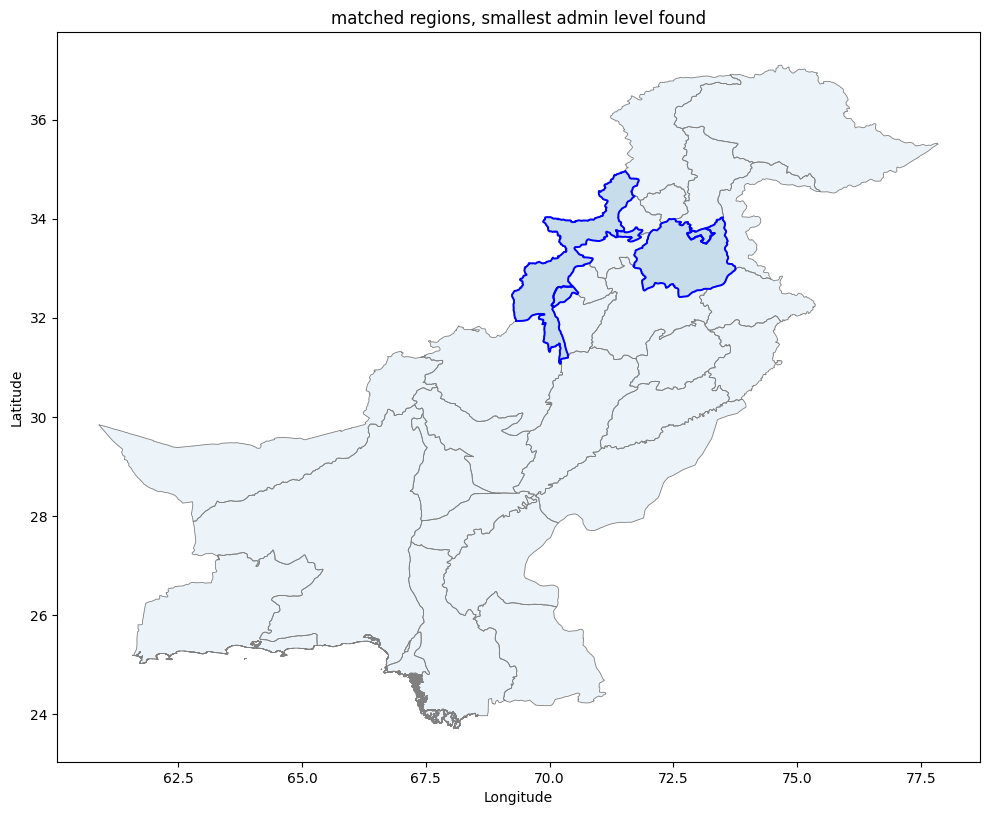

In [4]:
summary_df, matched_polys = gadm_match_locations(
    gpkg_path,
    locations,
    country=country,
    json_path = event_folder,
)

fig, ax = plot_gadm_matches_onefig(
    gpkg_path,
    matched_polys,
    country = country,
    points_df=summary_df,  # must have latitude/longitude
    title='matched regions, smallest admin level found',
)
plt.show()

# population ghsl and worldpop

In [7]:
worldpop_results_df = extract_admin_age_sex_groups(
    summary_df=summary_df,
    matched_poly=matched_polys,
    worldpop_tif_dir=str(global_age_sex_path),
    json_path=event_folder,
    join_key="GID_2",
)

In [9]:
def get_totals(df, index):
    total_vulnerable = int(df["vulnerable_people"].sum())
    total_population = int(df["total_population"].sum())
    
    return {
        "total_vulnerable_people": total_vulnerable,
        "total_population": total_population,
        "total_vulnerable_people_indexed": int(total_vulnerable * index),
        "total_population_indexed": int(total_population * index),
    }


sdn = 0.0738  
syr = 0.7102  
pak = 0.5184  

print('for sudan')
totals = get_totals(worldpop_results_df, index=sdn)  # replace with your index value
for k, v in totals.items():
    print(f"{k}: {v:,}")
    
print('for syria')
totals = get_totals(worldpop_results_df, index=syr)  # replace with your index value
for k, v in totals.items():
    print(f"{k}: {v:,}")
    
print('for pakistan')
totals = get_totals(worldpop_results_df, index=pak)  # replace with your index value
for k, v in totals.items():
    print(f"{k}: {v:,}")

for sudan
total_vulnerable_people: 15,263,090
total_population: 20,031,978
total_vulnerable_people_indexed: 1,126,416
total_population_indexed: 1,478,359
for syria
total_vulnerable_people: 15,263,090
total_population: 20,031,978
total_vulnerable_people_indexed: 10,839,846
total_population_indexed: 14,226,710
for pakistan
total_vulnerable_people: 15,263,090
total_population: 20,031,978
total_vulnerable_people_indexed: 7,912,385
total_population_indexed: 10,384,577
